# 04 – XGBoost Training & Evaluation (B3 Forecast)

**Scope:** Compressors / US market – B3 revenue forecasting layer  
**Target:** `net_value_usd`  
**Validation:** TimeSeriesSplit (n=5) – no random splits to prevent data leakage  
**Metrics:** MAE, RMSE, sMAPE, WMAPE (no MAPE – negative target values present)

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pickle
import os

DATA_PROCESSED = '../data/processed/'
MODELS_DIR = '../models/'

os.makedirs(MODELS_DIR, exist_ok=True)

## 1 – Load & Filter Data

In [2]:
df_all = pd.read_csv(DATA_PROCESSED + 'feature_matrix.csv', parse_dates=['date'])

# Filter to Compressors only (sufficient sample size, lower volatility)
df = df_all[df_all['Product'] == 'Compressors'].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f'Rows: {len(df)}  |  Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Negative target values: {(df["net_value_usd"] < 0).sum()}')
df[['date', 'net_value_usd']].head()

Rows: 33  |  Date range: 2023-04-01 → 2025-12-01
Negative target values: 0


,date,net_value_usd
0,2023-04-01,2034605.0
1,2023-05-01,2240657.0
2,2023-06-01,2501235.0
3,2023-07-01,1797922.0
4,2023-08-01,1586807.0


In [3]:
# Define feature matrix and target
EXCLUDE = ['date', 'Product', 'net_value_usd']
FEATURES = [c for c in df.columns if c not in EXCLUDE]
TARGET = 'net_value_usd'

X = df[FEATURES].values
y = df[TARGET].values

print(f'Feature count: {len(FEATURES)}')
print('Features:', FEATURES)

Feature count: 35
Features: ['de_orders_index_lag_1', 'de_orders_index_lag_2', 'de_orders_index_lag_3', 'de_orders_index_lag_4', 'de_orders_index_lag_5', 'de_orders_index_lag_6', 'de_production_index_diff_lag_1', 'de_production_index_diff_lag_2', 'de_production_index_diff_lag_3', 'de_production_index_diff_lag_4', 'de_production_index_diff_lag_5', 'de_production_index_diff_lag_6', 'us_durable_goods_orders_musd_diff_lag_1', 'us_durable_goods_orders_musd_diff_lag_2', 'us_durable_goods_orders_musd_diff_lag_3', 'us_durable_goods_orders_musd_diff_lag_4', 'us_durable_goods_orders_musd_diff_lag_5', 'us_durable_goods_orders_musd_diff_lag_6', 'us_production_index_diff_lag_1', 'us_production_index_diff_lag_2', 'us_production_index_diff_lag_3', 'us_production_index_diff_lag_4', 'us_production_index_diff_lag_5', 'us_production_index_diff_lag_6', 'month', 'quarter', 'year', 'is_q4', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_3', 'revenue_rolling_3m_mean', 'revenue_rolling_3m_std', 'revenue_rolli

## 2 – Metric Definitions

- **sMAPE** – symmetric MAPE, handles zero/negative targets  
- **WMAPE** – weighted MAPE computed on positive-target observations only (avoids division-by-zero and sign distortion)

In [4]:
def smape(y_true, y_pred):
    """Symmetric MAPE – safe for zero/negative actuals."""
    denom = np.abs(y_true) + np.abs(y_pred)
    # Where both actual and predicted are exactly zero, contribution is zero
    mask = denom > 0
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def wmape(y_true, y_pred):
    """Weighted MAPE on positive actual values only."""
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.sum(np.abs(y_true[mask] - y_pred[mask])) / np.sum(np.abs(y_true[mask])) * 100

## 3 – TimeSeriesSplit Cross-Validation

In [5]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# XGBoost hyperparameters – fixed for prototype (dataset too small for reliable HPO)
XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

fold_results = []
oos_predictions = np.full(len(y), np.nan)  # collect out-of-sample predictions

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    oos_predictions[val_idx] = y_pred

    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    sp   = smape(y_val, y_pred)
    wm   = wmape(y_val, y_pred)

    fold_results.append({
        'Fold': fold,
        'Train size': len(train_idx),
        'Val size': len(val_idx),
        'MAE': mae,
        'RMSE': rmse,
        'sMAPE (%)': sp,
        'WMAPE (%)': wm,
    })
    print(f'Fold {fold}  train={len(train_idx):>2}  val={len(val_idx):>2}  '
          f'MAE={mae:,.0f}  RMSE={rmse:,.0f}  sMAPE={sp:.1f}%  WMAPE={wm:.1f}%')

Fold 1  train= 8  val= 5  MAE=478,941  RMSE=658,923  sMAPE=23.2%  WMAPE=23.3%


Fold 2  train=13  val= 5  MAE=380,709  RMSE=444,611  sMAPE=16.8%  WMAPE=16.1%


Fold 3  train=18  val= 5  MAE=487,373  RMSE=547,038  sMAPE=22.3%  WMAPE=21.2%


Fold 4  train=23  val= 5  MAE=361,323  RMSE=429,971  sMAPE=14.3%  WMAPE=13.6%


Fold 5  train=28  val= 5  MAE=492,655  RMSE=536,081  sMAPE=20.2%  WMAPE=19.8%


## 4 – Metrics Summary Table

In [6]:
metrics_df = pd.DataFrame(fold_results).set_index('Fold')

# Append mean and std rows
numeric_cols = ['MAE', 'RMSE', 'sMAPE (%)', 'WMAPE (%)']
mean_row = metrics_df[numeric_cols].mean().rename('Mean')
std_row  = metrics_df[numeric_cols].std().rename('Std')

summary = pd.concat([metrics_df, mean_row.to_frame().T, std_row.to_frame().T])

# Format numeric columns for display
display_df = summary.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda v: f'{v:,.1f}' if pd.notna(v) else 'n/a')

print('\nCross-Validation Results – Compressors / US')
print('=' * 70)
print(display_df[numeric_cols].to_string())


Cross-Validation Results – Compressors / US
            MAE       RMSE sMAPE (%) WMAPE (%)
1     478,941.0  658,923.4      23.2      23.3
2     380,708.8  444,611.1      16.8      16.1
3     487,373.2  547,037.7      22.3      21.2
4     361,323.2  429,971.3      14.3      13.6
5     492,655.0  536,081.4      20.2      19.8
Mean  440,200.2  523,325.0      19.3      18.8
Std    63,715.1   92,226.3       3.7       3.9


## 5 – Final Model (Full Dataset)

In [7]:
final_model = xgb.XGBRegressor(**XGB_PARAMS)
final_model.fit(X, y)

# In-sample fit for reference (not used as evaluation metric)
y_insample = final_model.predict(X)
print('Final model trained on full dataset.')
print(f'In-sample MAE:  {mean_absolute_error(y, y_insample):,.0f}')
print(f'In-sample RMSE: {np.sqrt(mean_squared_error(y, y_insample)):,.0f}')

Final model trained on full dataset.
In-sample MAE:  2,958
In-sample RMSE: 4,867


## 6 – Feature Importance (Top 20, Gain)

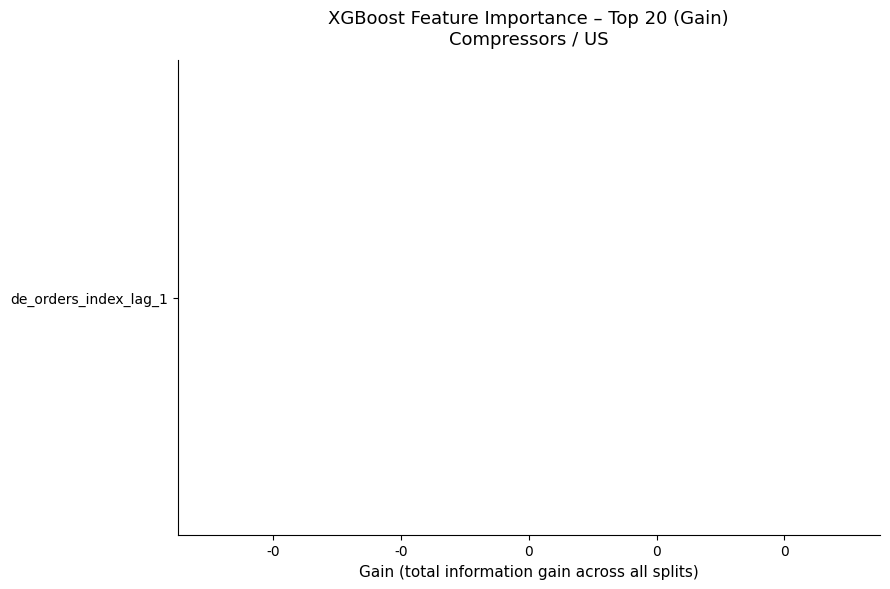

In [8]:
importance_scores = final_model.get_booster().get_score(importance_type='gain')
importance_series = pd.Series(importance_scores, index=FEATURES).reindex(FEATURES, fill_value=0)
top20 = importance_series.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top20.index, top20.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Gain (total information gain across all splits)', fontsize=11)
ax.set_title('XGBoost Feature Importance – Top 20 (Gain)\nCompressors / US', fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 7 – Actual vs. Predicted Timeline

Out-of-sample predictions assembled across all CV folds (walk-forward).  
The first ~6 observations (train-only in fold 1) have no OOS prediction.

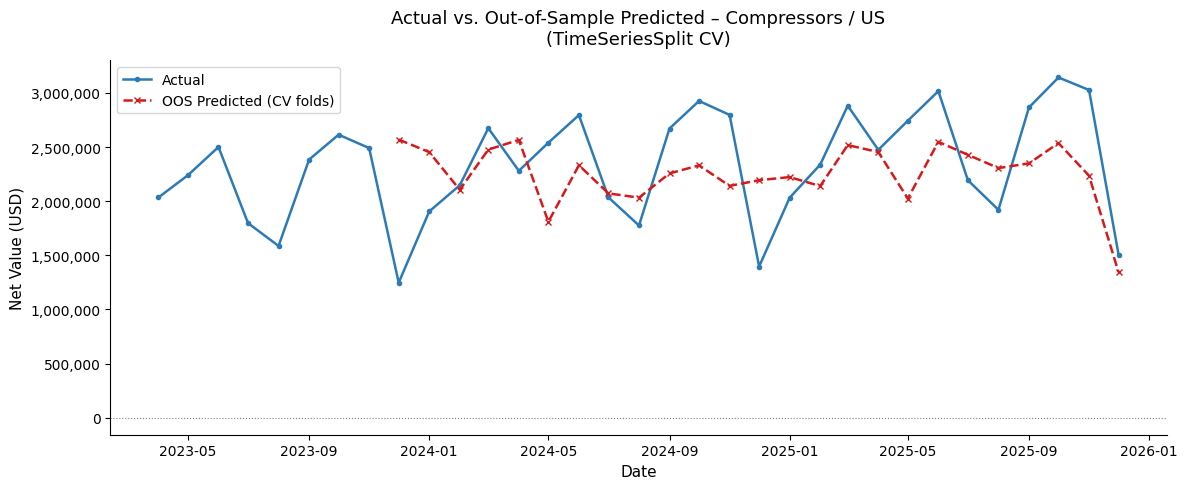

In [9]:
dates = df['date'].values

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, y, label='Actual', color='#2c7bb6', linewidth=1.8, marker='o', markersize=3)
ax.plot(
    dates, oos_predictions,
    label='OOS Predicted (CV folds)', color='#d7191c',
    linewidth=1.8, linestyle='--', marker='x', markersize=4
)

# Mark negative actual values
neg_mask = y < 0
if neg_mask.any():
    ax.scatter(dates[neg_mask], y[neg_mask], color='orange', zorder=5,
               s=50, label='Negative actual', marker='D')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Net Value (USD)', fontsize=11)
ax.set_title('Actual vs. Out-of-Sample Predicted – Compressors / US\n(TimeSeriesSplit CV)', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8 – Save Model

In [10]:
MODEL_PATH = MODELS_DIR + 'xgboost_compressors_us.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump({'model': final_model, 'features': FEATURES}, f)

print(f'Model saved → {MODEL_PATH}')

Model saved → ../models/xgboost_compressors_us.pkl


## 9 – Summary & Limitations

### Results

The XGBoost model was trained and evaluated on 33 monthly observations (Compressors / US)  
using a **5-fold TimeSeriesSplit** walk-forward cross-validation to prevent data leakage.

Key design choices:
- **No StandardScaler** applied to features – XGBoost is scale-invariant
- **No hyperparameter optimization** – sample size too small for reliable tuning without overfitting
- **sMAPE / WMAPE** instead of MAPE – 10 negative target values make classic MAPE undefined
- **Accessories / US excluded** – n too small, high volatility (see analysis in 03_feature_engineering)

### Limitations

> **Synthetic data basis:** The revenue figures are generated from a simulated SAP export.  
> All numeric metrics (MAE, RMSE, sMAPE, WMAPE) demonstrate the **methodological pipeline**  
> and should not be interpreted as real forecast quality.  
> Evaluation on real production data is required before drawing business conclusions.

The trained model is saved to `models/xgboost_compressors_us.pkl` and will be used in  
`05_shap_analysis.ipynb` for interpretability analysis (SHAP values with StandardScaler for visualization only).